# Taller de Aprendizaje No Supervisado
## Parte 1: Dataset de Setas (variables categóricas)

### Mushroom Dataset

Podéis obtener el conjunto de datos en el siguiente enlace:

[Mushroom Dataset](https://www.kaggle.com/uciml/mushroom-classification)

Como podréis comprobar, hay **muchas variables, todas categóricas**, por lo que las exploraciones con *scatterplot* no nos serán útiles como en otros casos.

La variable a predecir es `class` (`e` = comestible / *edible*, `p` = venenosa / *poisonous*) y es **binaria**.

> En este taller usaremos las etiquetas **solo para validar** lo que descubre el clustering. La idea del aprendizaje no supervisado es encontrar estructura *sin* mirar la etiqueta.

### Algoritmos que cubriremos

**Reducción de dimensionalidad:** PCA (lineal) y t-SNE (no lineal).

**Clustering:** K-Means, Clustering Jerárquico (Aglomerativo), Gaussian Mixture Models (GMM) y DBSCAN.

**Evaluación:** método del codo, *silhouette*, Davies-Bouldin, Calinski-Harabasz y (como tenemos etiqueta) Adjusted Rand Index y NMI.

**Detección de anomalías:** Isolation Forest.

In [127]:
# Carga de librerias, las que hemos considerado basicas, añadid lo que querais :)
# Importad aqui el resto de algoritmos a medida que los necesiteis:
# TSNE, AgglomerativeClustering, DBSCAN, GaussianMixture, IsolationForest, metricas...
%matplotlib inline
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.metrics import accuracy_score, silhouette_score, adjusted_rand_score, normalized_mutual_info_score, davies_bouldin_score,calinski_harabasz_score
from sklearn.manifold import TSNE
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.mixture import GaussianMixture
import umap.umap_ as umap
import hdbscan
from mlxtend.frequent_patterns import apriori, association_rules

sns.set_theme(style='whitegrid')
RANDOM_STATE = 42

### Leer conjunto de datos y primer vistazo

In [128]:
# Leer el csv (esta en 'data/mushrooms.csv') y sacar por pantalla las cinco primeras filas.
df = pd.read_csv("data/mushrooms.csv")

df.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


### Exploración de datos

In [129]:
# Descripcion del conjunto de datos, estandar.
df.describe(include="all")

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
count,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,...,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124
unique,2,6,4,10,2,9,2,2,2,12,...,4,9,9,1,4,3,5,9,6,7
top,e,x,y,n,f,n,f,c,b,b,...,s,w,w,p,w,o,p,w,v,d
freq,4208,3656,3244,2284,4748,3528,7914,6812,5612,1728,...,4936,4464,4384,8124,7924,7488,3968,2388,4040,3148


In [130]:
# Informacion sobre el tipo de datos de cada feature.
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   class                     8124 non-null   str  
 1   cap-shape                 8124 non-null   str  
 2   cap-surface               8124 non-null   str  
 3   cap-color                 8124 non-null   str  
 4   bruises                   8124 non-null   str  
 5   odor                      8124 non-null   str  
 6   gill-attachment           8124 non-null   str  
 7   gill-spacing              8124 non-null   str  
 8   gill-size                 8124 non-null   str  
 9   gill-color                8124 non-null   str  
 10  stalk-shape               8124 non-null   str  
 11  stalk-root                8124 non-null   str  
 12  stalk-surface-above-ring  8124 non-null   str  
 13  stalk-surface-below-ring  8124 non-null   str  
 14  stalk-color-above-ring    8124 non-null   str  
 15

In [131]:
df.shape

(8124, 23)

#### Calcular el número de nulos de cada feature

In [132]:
# Igual que otras veces, una linea: contar los nulos por variable.
df.isnull().sum()

class                       0
cap-shape                   0
cap-surface                 0
cap-color                   0
bruises                     0
odor                        0
gill-attachment             0
gill-spacing                0
gill-size                   0
gill-color                  0
stalk-shape                 0
stalk-root                  0
stalk-surface-above-ring    0
stalk-surface-below-ring    0
stalk-color-above-ring      0
stalk-color-below-ring      0
veil-type                   0
veil-color                  0
ring-number                 0
ring-type                   0
spore-print-color           0
population                  0
habitat                     0
dtype: int64

#### Buscar valores extraños. Para ello, ver los valores únicos en cada feature

In [133]:
# Obtener un nuevo dataframe: en una columna las features (feature)
# y en la otra el numero de valores unicos asociados (n_values).
# n_values = ...
n_values = df.nunique().reset_index()
n_values.columns = ["feature", "n_values"]

display(n_values)

# Columnas con un único valor (no aportan información)
print("Columnas con un único valor:")
print(n_values[n_values["n_values"] == 1]["feature"].tolist())

# Columnas que contienen '?'
print("\nColumnas con '?':")
print([col for col in df.columns if "?" in df[col].values])

,feature,n_values
0,class,2
1,cap-shape,6
2,cap-surface,4
3,cap-color,10
4,bruises,2
5,odor,9
6,gill-attachment,2
7,gill-spacing,2
8,gill-size,2
9,gill-color,12


Columnas con un único valor:
['veil-type']

Columnas con '?':
['stalk-root']


Observad dos cosas:
- `veil-type` tiene **un único valor** → no aporta información.
- `stalk-root` contiene el valor `'?'`, que en realidad es un **valor desconocido (nulo encubierto)**.

#### Tratar aquellos valores que entendamos que sean nulos

In [134]:
# Imputaciones. Podeis quitar esos puntos (fila entera), imputar con la moda
# o dejar ese valor como una posibilidad mas. Aqui imputamos '?' con la moda.
df["stalk-root"] = df["stalk-root"].replace("?", np.nan)
df["stalk-root"] = df["stalk-root"].fillna(df["stalk-root"].mode()[0])
print(df["stalk-root"].unique())
print(df["stalk-root"].isna().sum())

<StringArray>
['e', 'c', 'b', 'r']
Length: 4, dtype: str
0


#### ¿Todas las features aportan información? Si alguna no aporta, eliminadla

In [135]:
# Dejar por el camino las features con un solo valor (no aportan nada).
cols_remove = n_values[n_values["n_values"] == 1]["feature"]

df = df.drop(columns=cols_remove)
df.shape

(8124, 22)

#### Separar entre variables predictoras y variable a predecir

In [136]:
# La variable a predecir es 'class'.
y = df["class"]
X = df.drop(columns="class")

#### Codificar correctamente las variables categóricas a numéricas

In [137]:
# One Hot Encoder (una linea). Pista: pd.get_dummies
X = pd.get_dummies(X)

#### Train / test split

In [138]:
# Os lo dejamos a todos igual
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

## PCA

Es un conjunto de datos del que aún no hemos visto gráficas, así que vamos a hacer algunas. Tenemos muchas variables, **PCA al rescate**: le pedimos dos dimensiones y las pintamos. Serán **las que retengan más información (varianza)**.

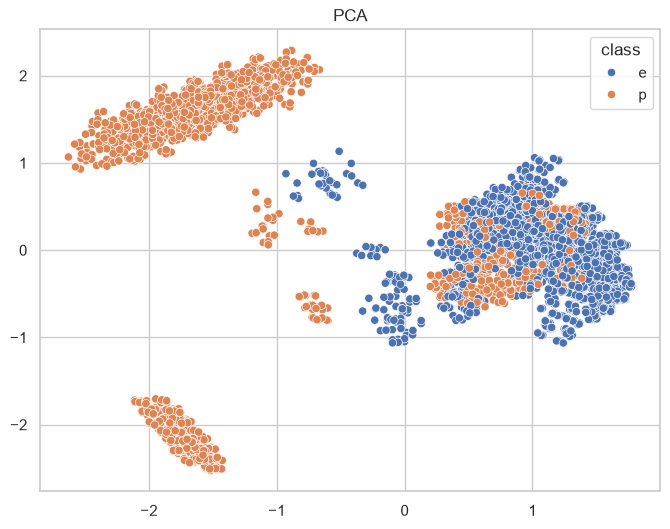

In [139]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)

X_train_pca = pca.fit_transform(X_train)

# Representar en un scatterplot y poner en color las etiquetas de entrenamiento
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=X_train_pca[:,0],
    y=X_train_pca[:,1],
    hue=y_train
)

plt.title("PCA")
plt.show()

Parece que está bastante separadito, ¡a ojo mucho se puede ver! :)

Antes de seguir, entrenamos un clasificador supervisado como **línea base** (así sabemos cuánta información hay realmente en los datos).

In [140]:
# 1. Definir el clasificador y el numero de estimadores
# 2. Entrenar en train
# 3. Calcular la precision sobre test
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=RANDOM_STATE
)

rf.fit(X_train, y_train)

pred = rf.predict(X_test)

accuracy_score(y_test, pred)

1.0

Es un conjunto sencillo y Random Forest es muy bueno. Veamos cuántas features tenemos:

In [141]:
X_train.shape

(5443, 115)

¿Muchas features, no? Vamos a reducirlas con PCA y ver cuántas componentes necesita Random Forest para mantener su precisión.

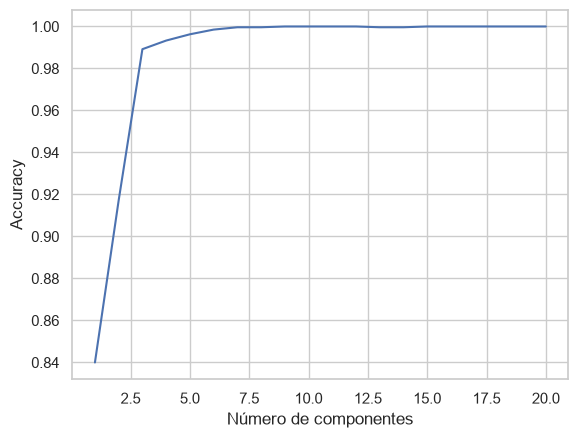

In [142]:
n_features = range(1, 21)  # definir un rango de valores a probar
scores = []

# 1. Definir y ajustar PCA sobre X_train (máximo número de componentes)
pca = PCA(n_components=max(n_features))
Xtr_full = pca.fit_transform(X_train)
Xts_full = pca.transform(X_test)

for n in n_features:

    # usamos solo las primeras n componentes
    Xtr = Xtr_full[:, :n]
    Xts = Xts_full[:, :n]

    # 2. Entrenar Random Forest sobre los datos reducidos
    rf = RandomForestClassifier(
        n_estimators=50,
        random_state=RANDOM_STATE
    )

    rf.fit(Xtr, y_train)

    # 3. Guardar el score en test
    scores.append(rf.score(Xts, y_test))

sns.lineplot(x=list(n_features), y=scores)

plt.xlabel("Número de componentes")
plt.ylabel("Accuracy")
plt.show()

A partir de ~10 componentes ya tenemos la precisión que queríamos, reduciendo las variables a una fracción de las originales.

---
## t-SNE: reducción **no lineal** para visualizar

PCA es lineal. **t-SNE** intenta preservar la vecindad local y suele separar mejor los grupos visualmente. Es más caro, así que lo calculamos sobre una **muestra**.

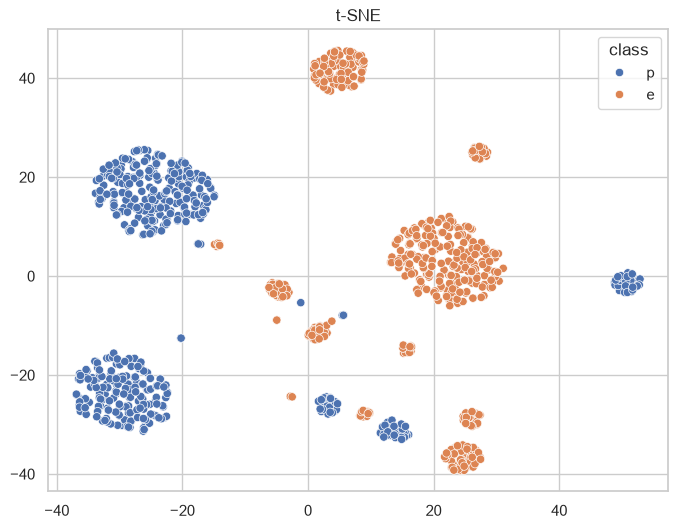

In [143]:
# 1. Tomar una muestra de X_train (t-SNE es lento)
muestra = X_train.sample(1000, random_state=42)

y_muestra = y_train.loc[muestra.index]

# 2. Definir TSNE(n_components=2, ...) y ajustar
tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=30
)

X_tsne = tsne.fit_transform(muestra)

# 3. Pintar el embedding coloreado por la etiqueta
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=X_tsne[:,0],
    y=X_tsne[:,1],
    hue=y_muestra
)

plt.title("t-SNE")
plt.show()

---
## Clustering

El conjunto es sencillito, así que probemos clustering para ver qué información obtenemos **sin usar las etiquetas**. Trabajaremos sobre una representación reducida con PCA (10 componentes), que limpia ruido y acelera los algoritmos.

In [144]:
# Reducir X (one-hot completo) a 10 componentes con PCA -> X_red
pca = PCA(n_components=10)

X_red = pca.fit_transform(X)

### K-Means: ¿cuántos clusters? Codo + Silhouette

El **método del codo** mira la inercia (suma de distancias a los centroides). El **coeficiente de silhouette** mide cómo de bien separados están los clusters (cuanto más alto, mejor). Usamos ambos.

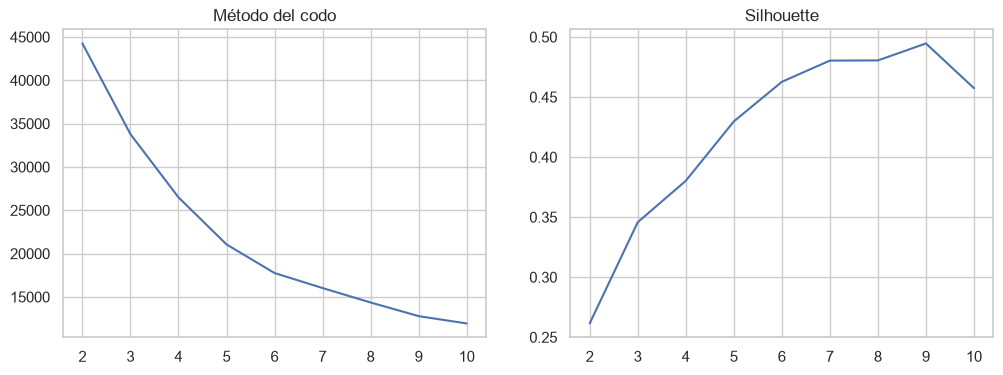

In [145]:
k_values = range(2,11) # definir un rango
inercias, silhouettes = [], []
for k in k_values:
    # Definir KMeans y ajustar sobre X_red
    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = km.fit_predict(X_red)
    # Guardar la inercia (km.inertia_) y el silhouette_score
    inercias.append(km.inertia_)

    silhouettes.append(
        silhouette_score(X_red, labels)
    )

# Pintar las dos curvas (codo y silhouette)
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(k_values, inercias)

plt.title("Método del codo")

plt.subplot(1,2,2)
plt.plot(k_values, silhouettes)

plt.title("Silhouette")

plt.show()

### K-Means final y comparación con la etiqueta

Sabemos que hay dos clases (comestible / venenosa), así que probamos `k=2`. Con `catplot` vemos la distribución de la etiqueta real dentro de cada cluster.

ARI: 0.6170564946596258
NMI: 0.566282507939517


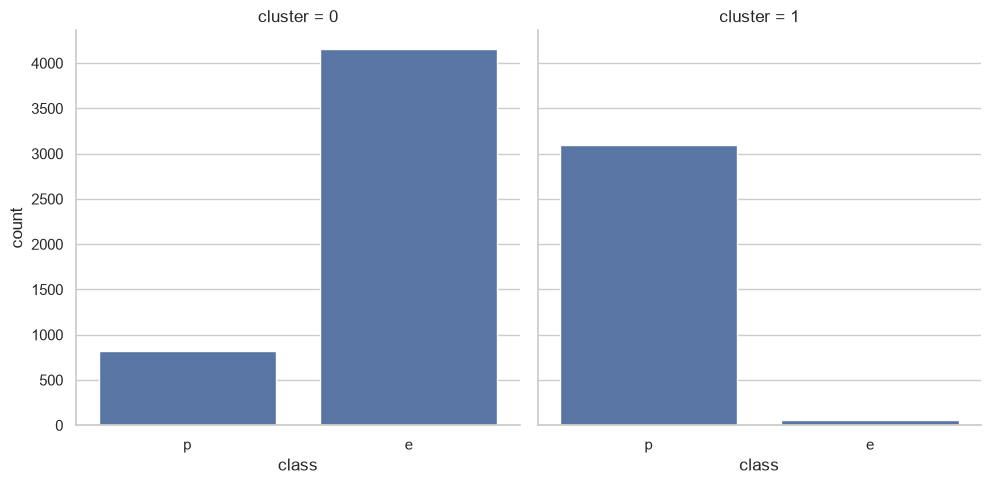

In [146]:
# Aprender KMeans con el k obtenido y preparar el catplot.
kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_red)

tmp = pd.DataFrame({
    "cluster": clusters,
    "class": y.reset_index(drop=True)
})

# ax = sns.catplot(col=, x=, data=, kind='count', col_wrap=4)
sns.catplot(
    data=tmp,
    x="class",
    col="cluster",
    kind="count",
    col_wrap=2
)

# Calcular ARI y NMI frente a y_bin
y_bin = y.map({"e": 0, "p": 1})

ari = adjusted_rand_score(y_bin, clusters)
nmi = normalized_mutual_info_score(y_bin, clusters)

print("ARI:", ari)
print("NMI:", nmi)

> **ARI / NMI** comparan los clusters con la etiqueta real (0 = aleatorio, 1 = idéntico). Sin haber visto la etiqueta, K-Means recupera buena parte de la estructura comestible/venenosa, pero **no es perfecto**: ese es el reto real del no supervisado.

### Comparativa de algoritmos de clustering

Vamos a poner a competir **K-Means, Aglomerativo, GMM y DBSCAN** con varias métricas. Las tres primeras métricas son *internas* (no usan etiqueta); ARI sí la usa, para validar.

In [147]:
# Definir una funcion evaluar(nombre, labels, X) que devuelva silhouette,
# davies_bouldin, calinski_harabasz y ARI.
def evaluar(nombre, labels, X):

    return {
        "Algoritmo": nombre,
        "Silhouette": silhouette_score(X, labels),
        "Davies": davies_bouldin_score(X, labels),
        "Calinski": calinski_harabasz_score(X, labels),
        "ARI": adjusted_rand_score(y_bin, labels)
    }

# Aplicarla a KMeans, AgglomerativeClustering, GaussianMixture y DBSCAN
# y montar una tabla (DataFrame) comparativa.
resultados = []

# KMeans
labels = KMeans(n_clusters=2, random_state=42).fit_predict(X_red)
resultados.append(evaluar("KMeans", labels, X_red))

# Aglomerativo
labels = AgglomerativeClustering(n_clusters=2).fit_predict(X_red)
resultados.append(evaluar("Aglomerativo", labels, X_red))

# GMM
labels = GaussianMixture(
    n_components=2,
    random_state=42
).fit_predict(X_red)

resultados.append(evaluar("GMM", labels, X_red))

# DBSCAN
labels = DBSCAN(
    eps=1,
    min_samples=5
).fit_predict(X_red)

# DBSCAN incluye ruido (-1), pero aquí lo mantenemos para comparación justa
resultados.append(evaluar("DBSCAN", labels, X_red))

# Tabla comparativa final
pd.DataFrame(resultados)

,Algoritmo,Silhouette,Davies,Calinski,ARI
0,KMeans,0.261416,1.692939,2564.691274,0.617056
1,Aglomerativo,0.258872,1.696264,2503.624971,0.608952
2,GMM,0.257873,1.700914,2500.017463,0.598621
3,DBSCAN,0.379183,0.972554,1552.307595,0.175342


### Dendrograma (clustering jerárquico)

El clustering aglomerativo construye una jerarquía que podemos visualizar como **dendrograma**. La altura a la que se unen dos grupos indica cómo de distintos son. Lo calculamos sobre una muestra para que se lea bien.

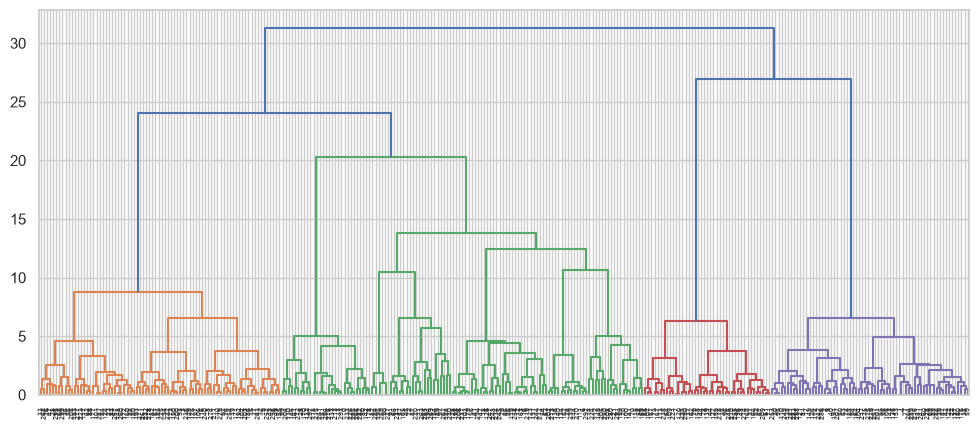

In [148]:
# 1. Tomar una muestra de X_red
np.random.seed(42)
muestra = X_red[np.random.choice(len(X_red),300,replace=False)]
# 2. linkage(..., method='ward')
Z = linkage(
    muestra,
    method="ward"
)
# 3. dendrogram(...) para visualizar la jerarquia
plt.figure(figsize=(12,5))

dendrogram(Z)

plt.show()

### DBSCAN: la **métrica de distancia importa**

DBSCAN agrupa por densidad. Pero con datos **categóricos** codificados en one-hot, la distancia euclídea no captura bien la similitud. Comparemos euclídea (sobre PCA) con la distancia de **Jaccard** (pensada para datos binarios).

In [149]:
# Comparar DBSCAN con metric='euclidean' (sobre X_red) y metric='jaccard'
# (sobre el one-hot binario). Observar cual recupera mejor la estructura (ARI).
db = DBSCAN(
    eps=0.3,
    min_samples=5,
    metric="jaccard"
)

# Ajuste del modelo
labels = db.fit_predict(X.astype(bool))

# Evaluación correcta (sin eliminar ruido)
print(
    "ARI (DBSCAN Jaccard):",
    adjusted_rand_score(y_bin, labels)
)

ARI (DBSCAN Jaccard): 0.2620992931066008


> **Lección:** con datos categóricos, elegir la distancia adecuada (Jaccard/Hamming) puede cambiar por completo el resultado de un algoritmo basado en densidad. No hay un algoritmo que gane siempre: depende del tipo de datos.

### Visualización final: clusters vs etiqueta real

Repetimos el scatter PCA, pero coloreando por el cluster de K-Means y por la etiqueta real, lado a lado.

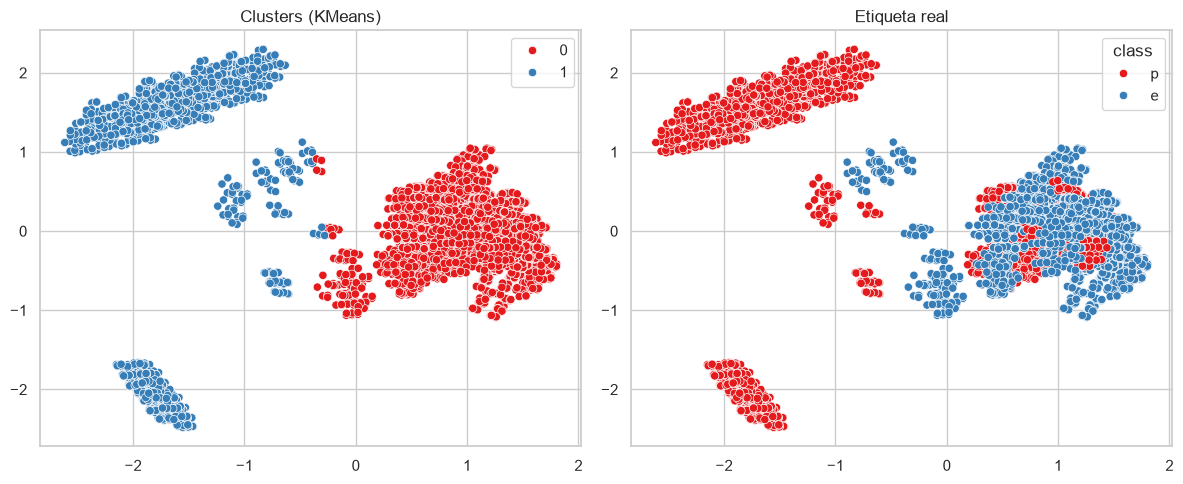

In [150]:
# Entrenar PCA(2) sobre X para representar.
# Pintar dos scatter: uno coloreado por el cluster de KMeans y otro por la etiqueta real.

pca2 = PCA(n_components=2)

coord = pca2.fit_transform(X_red)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Scatter de clusters
sns.scatterplot(
    x=coord[:, 0],
    y=coord[:, 1],
    hue=clusters,
    ax=ax[0],
    palette="Set1"
)

ax[0].set_title("Clusters (KMeans)")

# Scatter de etiqueta real
sns.scatterplot(
    x=coord[:, 0],
    y=coord[:, 1],
    hue=y.reset_index(drop=True),
    ax=ax[1],
    palette="Set1"
)

ax[1].set_title("Etiqueta real")

plt.tight_layout()
plt.show()

Es bastante parecido, ¿no? No es tan bueno como Random Forest (que usa etiquetas), pero K-Means ha identificado bastante bien la estructura **sin usarlas**. Si no tuviéramos etiquetas, esta aproximación nos ayudaría mucho a clasificar los tipos de hongos.

---
## Detección de anomalías (Isolation Forest)

Una tarea no supervisada distinta: encontrar las muestras **atípicas**. Isolation Forest aísla los puntos raros con pocos cortes aleatorios.

Total muestras: 8124
Anomalías: 163
Normales: 7961


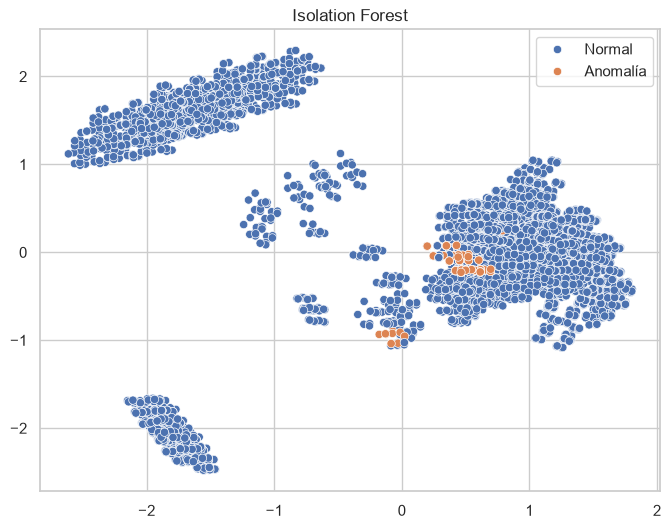

In [151]:
# 1. Definir IsolationForest(contamination=...) y ajustar sobre X_red
# 2. predict -> -1 son anomalias
# 3. Pintarlas sobre la proyeccion PCA
iso = IsolationForest(
    contamination=0.02,
    random_state=42
)

anomalias = iso.fit_predict(X_red)

# Número de anomalías detectadas
num_anomalias = np.sum(anomalias == -1)
num_normales = np.sum(anomalias == 1)
total = len(anomalias)

print("Total muestras:", total)
print("Anomalías:", num_anomalias)
print("Normales:", num_normales)

# Convertimos a algo más interpretable para el gráfico
labels_plot = np.where(anomalias == -1, "Anomalía", "Normal")

plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=coord[:, 0],
    y=coord[:, 1],
    hue=labels_plot
)

plt.title("Isolation Forest")
plt.show()

---
## Para ir más allá (opcional)

- **UMAP** (`pip install umap-learn`): alternativa a t-SNE, más rápida y preserva mejor la estructura global.
- **HDBSCAN** (`pip install hdbscan`): DBSCAN jerárquico que no necesita fijar `eps`.
- **Reglas de asociación** (`mlxtend`, Apriori/FP-Growth): muy naturales aquí por ser datos categóricos; permiten descubrir reglas tipo «si olor = X entonces venenosa».

## UMAP

c:\Users\elena\OneDrive\Escritorio\bootcamp-da-p2\DA-Project-Unsupervised-ML-Equipo4\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


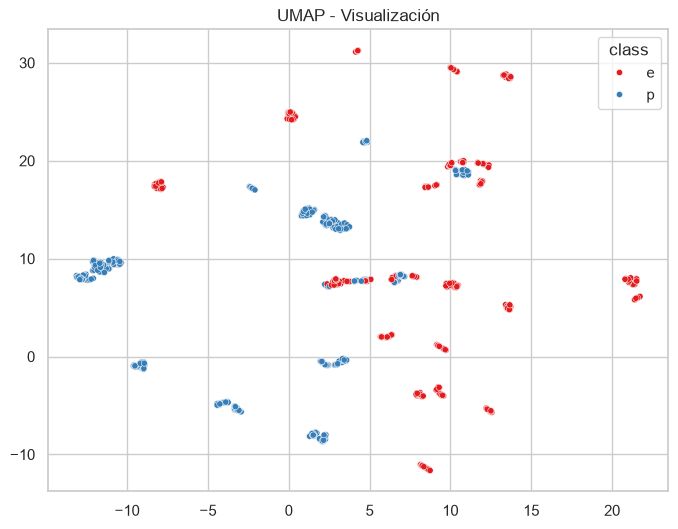

In [152]:
# Muestra pequeña para que vaya rápido
idx = np.random.choice(len(X_red), 1000, replace=False)

X_sample = X_red[idx]
y_sample = y.reset_index(drop=True).iloc[idx]

umap_model = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.2,
    random_state=42,
    n_jobs=-1
)

X_umap = umap_model.fit_transform(X_sample)

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=X_umap[:,0],
    y=X_umap[:,1],
    hue=y_sample,
    palette="Set1",
    s=20
)

plt.title("UMAP - Visualización")
plt.show()

UMAP muestra los datos en 2D manteniendo las relaciones de cercanía entre puntos. Que aparezcan varios grupos pequeños y algo dispersos es normal en este tipo de datos, ya que hay muchas combinaciones distintas de características en las setas. No se busca una forma “bonita”, sino que los puntos similares queden cerca entre sí, lo cual ayuda a ver la estructura general del dataset.

## HDBSCAN

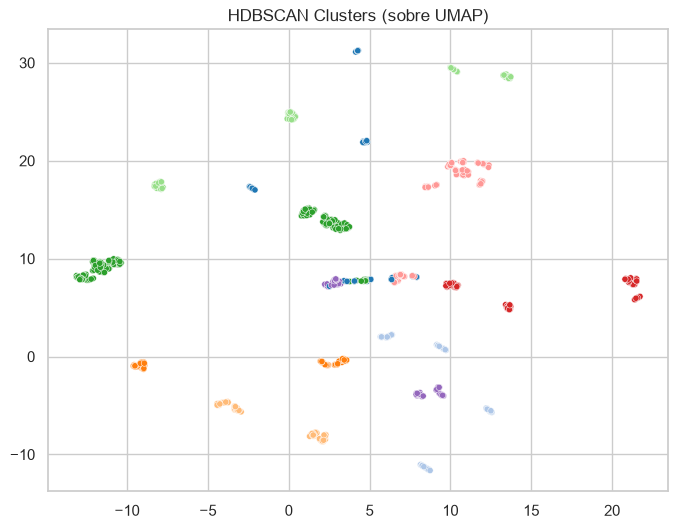

ARI (HDBSCAN): 0.19538854378097634


In [153]:
hdb = hdbscan.HDBSCAN(
    min_cluster_size=50,
    min_samples=10
)

labels_hdb = hdb.fit_predict(X_sample)

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=X_umap[:,0],
    y=X_umap[:,1],
    hue=labels_hdb,
    palette="tab20",
    legend=False,
    s=20
)

plt.title("HDBSCAN Clusters (sobre UMAP)")
plt.show()

# ARI
y_sample_bin = y_bin.iloc[idx]

print("ARI (HDBSCAN):",
      adjusted_rand_score(y_sample_bin, labels_hdb))

El HDBSCAN genera múltiples grupos pequeños en la proyección UMAP, en lugar de una separación clara entre comestibles y venenosas. Esto indica que está captando estructuras locales de densidad, pero no la división principal del problema. El ARI obtenido (~0.19) confirma esta baja correspondencia con la etiqueta real, por lo que no resulta un buen ajuste para este dataset.

## Reglas de asociación

In [154]:
# Usamos el dataset one-hot (antes de PCA)
df_rules = X.sample(2000, random_state=42)

# Apriori: encontrar itemsets frecuentes
frequent_itemsets = apriori(
    df_rules,
    min_support=0.1,
    use_colnames=True,
    max_len=2
)

# Generar reglas
rules = association_rules(
    frequent_itemsets,
    metric="confidence",
    min_threshold=0.7
)

# Ordenar por fuerza de la regla
rules = rules.sort_values("lift", ascending=False)

rules.head(10)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
345,frozenset({spore-print-color_h}),frozenset({ring-type_l}),0.2055,0.1640,0.1640,0.798054,4.866180,1.0,0.130298,4.139711,1.000000,0.798054,0.758437,0.899027
344,frozenset({ring-type_l}),frozenset({spore-print-color_h}),0.1640,0.2055,0.1640,1.000000,4.866180,1.0,0.130298,inf,0.950359,0.798054,1.000000,0.899027
98,frozenset({ring-type_l}),frozenset({odor_f}),0.1640,0.2680,0.1640,1.000000,3.731343,1.0,0.120048,inf,0.875598,0.611940,1.000000,0.805970
100,frozenset({spore-print-color_h}),frozenset({odor_f}),0.2055,0.2680,0.2000,0.973236,3.631478,1.0,0.144926,27.350182,0.912058,0.731261,0.963437,0.859752
99,frozenset({odor_f}),frozenset({spore-print-color_h}),0.2680,0.2055,0.2000,0.746269,3.631478,1.0,0.144926,3.131265,0.989932,0.731261,0.680640,0.859752
287,frozenset({ring-type_l}),frozenset({stalk-surface-below-ring_k}),0.1640,0.2875,0.1640,1.000000,3.478261,1.0,0.116850,inf,0.852273,0.570435,1.000000,0.785217
216,frozenset({spore-print-color_w}),frozenset({gill-color_b}),0.2885,0.2115,0.2115,0.733102,3.466205,1.0,0.150482,2.954315,1.000000,0.733102,0.661512,0.866551
215,frozenset({gill-color_b}),frozenset({spore-print-color_w}),0.2115,0.2885,0.2115,1.000000,3.466205,1.0,0.150482,inf,0.902346,0.733102,1.000000,0.866551
271,frozenset({ring-type_l}),frozenset({stalk-surface-above-ring_k}),0.1640,0.2905,0.1640,1.000000,3.442341,1.0,0.116358,inf,0.848684,0.564544,1.000000,0.782272
201,frozenset({gill-color_b}),frozenset({gill-size_n}),0.2115,0.3190,0.2115,1.000000,3.134796,1.0,0.144031,inf,0.863665,0.663009,1.000000,0.831505


Las reglas muestran asociaciones muy fuertes entre características del hongo (confidence cercana a 1 y lift alto), lo que indica que existen patrones estructurados en los datos categóricos. Estas relaciones ayudan a entender la dependencia entre variables incluso sin usar la etiqueta de clase.


## Conclusiones

- PCA y t-SNE nos dejaron *ver* un dataset de >100 dimensiones.
- K-Means, GMM y Aglomerativo recuperan la estructura comestible/venenosa con ARI ~0.6 **sin usar la etiqueta**.
- DBSCAN nos enseñó que **la métrica de distancia importa** con datos categóricos.
- Isolation Forest localiza las setas más atípicas.
- El no supervisado no da una respuesta «perfecta», pero descubre estructura muy útil cuando no tenemos etiquetas.